# BrainScanAI — Notebook 1 : exploration, features et clustering

**Contexte.** CurelyticsIA veut savoir s'il est possible d'automatiser la détection de tumeurs cérébrales sur IRM. Sur 1 500 images, seules 100 ont été annotées par des radiologues (normal / cancer) ; le reste n'a aucune étiquette.

**Objectif de ce notebook :**
1. Explorer le jeu de données
2. Préparer les images et extraire des features avec un modèle pré-entraîné
3. Réduire la dimension, appliquer un clustering et produire des labels « faibles »

---

## Étape 1 — Exploration du jeu de données

Avant tout traitement, on vérifie ce qu'on a réellement entre les mains : nombre d'images, dimensions, canaux de couleur, qualité des fichiers. Chaque anomalie repérée ici peut fausser les étapes suivantes.

### 1.1 Imports et chemin des données

Tout le chemin vers les données tient dans une seule variable `DATA_DIR` : c'est la seule ligne à modifier si on exécute le notebook ailleurs (sur Colab par exemple).

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Dossier du dataset (à adapter si on travaille sur Colab)
DATA_DIR = Path("../mri_dataset_brain_cancer_oc")

### 1.2 Inventaire des images

On parcourt tous les fichiers `.jpg` et on range leurs informations dans un DataFrame. Le sous-ensemble (`avec_labels` / `sans_label`) et le label (`cancer` / `normal`) se déduisent directement de l'arborescence des dossiers.

In [2]:
rows = []
for path in sorted(DATA_DIR.rglob("*.jpg")):
    rel = path.relative_to(DATA_DIR)
    subset = rel.parts[0]                                      # "avec_labels" ou "sans_label"
    label = rel.parts[1] if subset == "avec_labels" else None  # "cancer" / "normal", ou rien
    rows.append({"path": path, "subset": subset, "label": label})

df = pd.DataFrame(rows)

# Colonne pratique pour les graphiques : cancer / normal / sans_label
df["groupe"] = df["label"].fillna("sans_label")

print(f"{len(df)} images au total")
df["groupe"].value_counts()

1506 images au total


groupe
sans_label    1406
cancer          50
normal          50
Name: count, dtype: int64

### 1.3 Propriétés techniques des images

Pour chaque image, on lit ses dimensions, son mode couleur (`L` = niveaux de gris, `RGB` = couleur) et le poids du fichier. La doc annonce des images 512×512 : on vérifie que c'est bien le cas partout.

In [3]:
def image_info(path):
    """Ouvre l'image et renvoie ses caractéristiques techniques."""
    with Image.open(path) as img:
        return {"width": img.width, "height": img.height, "mode": img.mode, "format": img.format}

infos = pd.DataFrame([image_info(p) for p in df["path"]])
df = pd.concat([df, infos], axis=1)
df["file_kb"] = df["path"].apply(lambda p: p.stat().st_size / 1024)

# Combinaisons dimensions / mode couleur / format rencontrées
df.groupby(["width", "height", "mode", "format"]).size().rename("nb_images")

width  height  mode  format
512    512     RGB   JPEG      1506
Name: nb_images, dtype: int64

In [4]:
# Distribution du poids des fichiers (en Ko) par groupe
df.groupby("groupe")["file_kb"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
groupe,,,,,,,,
cancer,50.0,22.5,4.0,15.8,19.3,23.0,25.2,31.8
normal,50.0,29.1,11.4,17.4,23.0,25.3,29.4,64.3
sans_label,1406.0,24.1,5.8,13.1,20.6,23.2,26.6,73.7


### 1.4 Vraies couleurs ou niveaux de gris déguisés ?

Une IRM est par nature en niveaux de gris. Si les images sont stockées en RGB, les trois canaux devraient être (presque) identiques. On mesure pour chaque image l'écart maximal entre canaux : 0 = gris parfait. La compression JPEG peut créer de petits écarts, d'où un seuil de tolérance.

C'est important pour l'étape 2 : ResNet attend 3 canaux en entrée. Si les images sont grises, on dupliquera le canal gris.

In [5]:
def channel_diff(path):
    """Écart maximal entre les canaux R, G et B de l'image (0 = image grise)."""
    arr = np.asarray(Image.open(path).convert("RGB"), dtype=np.int16)
    return max(
        np.abs(arr[..., 0] - arr[..., 1]).max(),
        np.abs(arr[..., 1] - arr[..., 2]).max(),
    )

df["channel_diff"] = df["path"].apply(channel_diff)

TOLERANCE = 10  # écart toléré, lié à la compression JPEG
df["is_gray"] = df["channel_diff"] <= TOLERANCE

print(df["channel_diff"].describe().round(1))
df.groupby("groupe")["is_gray"].mean().rename("part_images_grises")

count    1506.0
mean        0.2
std         3.2
min         0.0
25%         0.0
50%         0.0
75%         0.0
max        81.0
Name: channel_diff, dtype: float64


groupe
cancer        1.00000
normal        1.00000
sans_label    0.99431
Name: part_images_grises, dtype: float64

### 1.5 Visualisation d'exemples

On affiche quelques images tirées au hasard dans chaque groupe. C'est l'étape la plus simple et souvent la plus instructive : cadrage, contraste, orientation, présence visible de la tumeur.

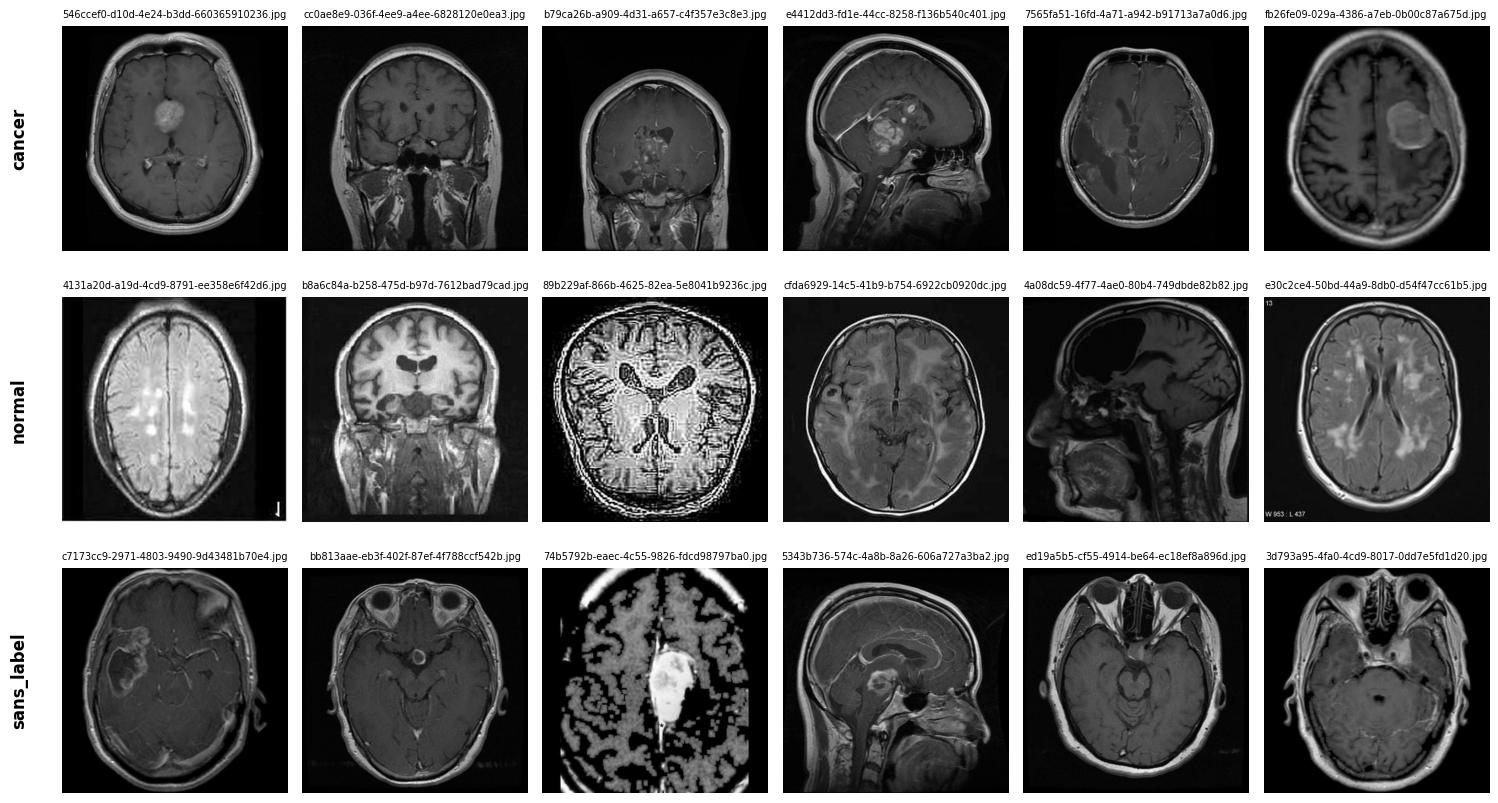

In [6]:
N_PER_ROW = 6
groupes = ["cancer", "normal", "sans_label"]

fig, axes = plt.subplots(len(groupes), N_PER_ROW, figsize=(2.5 * N_PER_ROW, 2.8 * len(groupes)))
for row, groupe in enumerate(groupes):
    # Tirage aléatoire reproductible (random_state fixé)
    sample = df[df["groupe"] == groupe].sample(N_PER_ROW, random_state=42)
    for col, path in enumerate(sample["path"]):
        ax = axes[row, col]
        ax.imshow(Image.open(path), cmap="gray")
        ax.set_title(path.name, fontsize=7)
        ax.axis("off")
    axes[row, 0].text(-0.15, 0.5, groupe, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.6 Qualité : fichiers corrompus et doublons

Deux vérifications :
- **Fichiers corrompus** : `Image.verify()` contrôle l'intégrité de chaque fichier.
- **Doublons exacts** : on calcule une empreinte MD5 du contenu de chaque fichier. Deux fichiers avec la même empreinte sont strictement identiques. Cela pourrait expliquer les 1 406 images sans label, alors que la doc en annonce 1 400.

Point d'attention : un doublon **entre** `avec_labels` et `sans_label` serait une fuite de données, puisque la même image se retrouverait à la fois dans le jeu fort et dans le jeu faible.

In [7]:
def is_valid(path):
    """True si le fichier image est lisible et non corrompu."""
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

df["is_valid"] = df["path"].apply(is_valid)
print(f"Fichiers corrompus : {(~df['is_valid']).sum()}")

# Empreinte MD5 du contenu de chaque fichier
df["md5"] = df["path"].apply(lambda p: hashlib.md5(p.read_bytes()).hexdigest())
dups = df[df.duplicated("md5", keep=False)].sort_values("md5")

print(f"Images impliquées dans un doublon : {len(dups)}")
print(f"Groupes de doublons : {dups['md5'].nunique()}")

# Doublons qui traversent plusieurs groupes (risque de fuite de données)
cross = dups.groupby("md5")["groupe"].nunique()
print(f"Groupes de doublons à cheval sur plusieurs groupes : {(cross > 1).sum()}")

dups[["md5", "groupe", "path"]].assign(path=dups["path"].apply(lambda p: p.name))

Fichiers corrompus : 0
Images impliquées dans un doublon : 186
Groupes de doublons : 90
Groupes de doublons à cheval sur plusieurs groupes : 31


,md5,groupe,path
651,038bd3a36c6463f3a9f18ac031ea1c4d,sans_label,63f74ae7-15f3-40e6-90f8-850dd20dbb70.jpg
988,038bd3a36c6463f3a9f18ac031ea1c4d,sans_label,a74cd797-2401-44e9-b29b-e3e125c8e148.jpg
1086,0652cb55477c4edeea5c5dfd53944e3b,sans_label,b65c7ebe-aac9-414e-a9d3-b8205d5d5a23.jpg
97,0652cb55477c4edeea5c5dfd53944e3b,normal,defdbef3-bea2-4f32-9d9a-62af1102ebfd.jpg
369,0816537db58c1d8092808f2c6f75e96c,sans_label,2f0c7977-339e-4e46-b412-c8fd1a8d05b0.jpg
...,...,...,...
51,fa2f6066ee4f4e22f35c46c4ddf8584b,normal,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg
187,fdc753e2225fcf328308438eb4f37058,sans_label,0e6c3f73-189a-420c-b17e-17dd19ac7736.jpg
579,fdc753e2225fcf328308438eb4f37058,sans_label,592e9fb8-cf27-4acf-ab1f-7644e76ff88e.jpg
1074,fe822536fc06483aeea76f22e3709f50,sans_label,b3d19755-4df5-4a8a-9206-92f244ea82bc.jpg


### 1.7 Traitement des doublons

Les 1 506 fichiers ne correspondent qu'à environ 1 410 images réellement différentes. On distingue trois cas, qui n'ont pas la même gravité :

| Cas | Conséquence si on ne fait rien |
| --- | --- |
| Plusieurs copies d'une même image dans `sans_label` | Certaines images pèsent 2 ou 3 fois plus que les autres dans le clustering et dans l'entraînement : un biais léger. |
| Deux copies d'une même image dans `normal` | On croit avoir 50 images normales alors qu'on n'en a que 49. |
| **Une image labellisée dont une copie se trouve dans `sans_label`** | **Fuite de données.** La copie recevrait un label faible et servirait à l'entraînement, alors que l'original peut finir dans le jeu de test fort. Le modèle serait évalué sur des images qu'il a déjà vues, et les scores du semi-supervisé seraient artificiellement gonflés. |

**Règle appliquée :** on ne garde qu'**une seule copie** de chaque image (identifiée par son empreinte MD5). Quand une image existe à la fois avec et sans label, c'est la **version labellisée qui est conservée** : l'étiquette d'un radiologue vaut plus qu'une étiquette faible, et on retire ainsi toute trace des images labellisées dans `sans_label`.

Les fichiers d'origine ne sont pas modifiés : on travaille sur un DataFrame nettoyé, `df_clean`, qui servira de référence pour toute la suite du projet.

In [8]:
# Priorité : une copie labellisée (0) passe avant une copie sans label (1)
priority = {"cancer": 0, "normal": 0, "sans_label": 1}

df_clean = (
    df.assign(prio=df["groupe"].map(priority))
      .sort_values(["prio", "path"])            # les copies labellisées passent en premier
      .drop_duplicates("md5", keep="first")     # on garde la première copie de chaque image
      .drop(columns="prio")
      .sort_index()
      .reset_index(drop=True)
)

# Vérification : plus aucune empreinte partagée entre images labellisées et non labellisées
md5_labels = set(df_clean.loc[df_clean["subset"] == "avec_labels", "md5"])
md5_sans_label = set(df_clean.loc[df_clean["subset"] == "sans_label", "md5"])
assert md5_labels.isdisjoint(md5_sans_label), "Fuite : une image labellisée est encore dans sans_label"

pd.DataFrame({
    "avant": df["groupe"].value_counts(),
    "après": df_clean["groupe"].value_counts(),
}).assign(retirées=lambda t: t["avant"] - t["après"])

,avant,après,retirées
groupe,,,
sans_label,1406,1311,95
cancer,50,50,0
normal,50,49,1


On sauvegarde l'inventaire nettoyé en CSV. Les chemins y sont stockés **relativement à `DATA_DIR`**, pour que le fichier reste utilisable si le dataset est placé ailleurs (sur Colab par exemple).

In [9]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

inventaire = df_clean[["path", "subset", "label", "groupe", "md5"]].copy()
inventaire["path"] = inventaire["path"].apply(lambda p: p.relative_to(DATA_DIR).as_posix())
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)

print(f"{len(inventaire)} images sauvegardées dans {OUTPUT_DIR / 'inventaire_images.csv'}")

1410 images sauvegardées dans ../outputs/inventaire_images.csv


### 1.8 Intensité des images

On calcule la luminosité moyenne de chaque image (moyenne des pixels en niveaux de gris, entre 0 et 255) et on compare les groupes, sur le jeu dédoublonné. Un écart marqué entre `cancer` et `normal` serait un signal à surveiller : le modèle pourrait apprendre à reconnaître la luminosité plutôt que la tumeur.

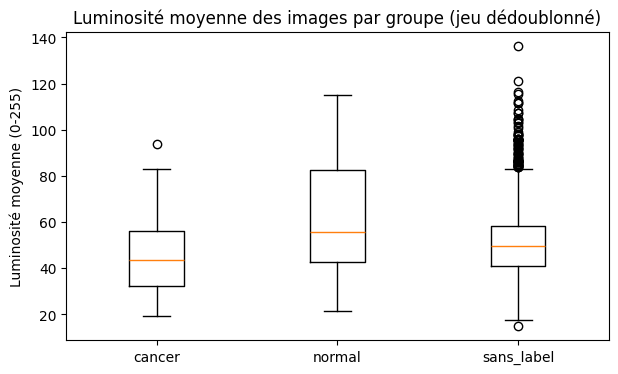

,count,mean,std,min,25%,50%,75%,max
groupe,,,,,,,,
cancer,50.0,46.0,15.5,19.5,32.5,43.6,56.2,94.0
normal,49.0,62.0,23.8,21.5,42.7,55.6,82.4,115.2
sans_label,1311.0,51.6,16.6,14.9,41.2,49.9,58.1,136.2


In [10]:
df_clean["mean_intensity"] = df_clean["path"].apply(lambda p: np.asarray(Image.open(p).convert("L")).mean())

fig, ax = plt.subplots(figsize=(7, 4))
data = [df_clean.loc[df_clean["groupe"] == g, "mean_intensity"] for g in groupes]
ax.boxplot(data, tick_labels=groupes)
ax.set_ylabel("Luminosité moyenne (0-255)")
ax.set_title("Luminosité moyenne des images par groupe (jeu dédoublonné)")
plt.show()

df_clean.groupby("groupe")["mean_intensity"].describe().round(1)

### 1.9 Observations

**Volume et format**
- 1 506 fichiers, mais seulement **1 410 images uniques** après dédoublonnage : **50 cancer, 49 normal, 1 311 sans label**. Les doublons expliquent l'écart avec la documentation, qui annonce 1 400 images sans label.
- Les images sont en **JPEG**, pas en PNG comme l'annonçait le mail de Clara.
- Format homogène : toutes les images font 512×512 pixels et aucun fichier n'est corrompu.

**Couleur**
- Toutes les images sont stockées en RGB, mais ce sont en réalité des **niveaux de gris** (canaux R, G et B identiques).
- 8 images sans label contiennent un peu de couleur : des bandeaux ou des textes bleus en bas de l'image, sur 0,01 % à 5,5 % des pixels. Ce sont probablement des captures d'écran de visionneuse. L'image médicale elle-même reste grise.
- Conséquence pour l'étape 2 : on convertit tout en niveaux de gris, puis on duplique ce canal sur 3 canaux, puisque ResNet attend une image RGB.

**Doublons**
- 96 fichiers retirés : 64 copies en trop dans `sans_label`, 1 dans `normal`, et surtout **31 images labellisées qui avaient une copie dans `sans_label`**. Sans ce nettoyage, ces copies auraient provoqué une fuite de données entre le jeu faible et le jeu de test fort.
- Limite : l'empreinte MD5 ne détecte que les copies **strictement identiques**. Des quasi-doublons (image recadrée ou recompressée) peuvent subsister. On pourra les repérer à l'étape 2 en comparant les embeddings.

**Hétérogénéité des images**
- Les IRM mélangent plusieurs **plans de coupe** (axial, coronal, sagittal) et plusieurs **séquences** d'acquisition (le contraste change d'une image à l'autre).
- Certaines images portent des annotations incrustées : textes, repères, valeurs de fenêtrage.
- Les images `cancer` semblent surtout acquises avec la même séquence, sur fond sombre, alors que les images `normal` sont plus variées et **plus claires** : leur luminosité médiane est de 55,6, contre 43,6 pour `cancer`.

**Point de vigilance pour la suite**
- Ce déséquilibre de séquences entre `cancer` et `normal` est un **biais potentiel**. À l'étape 3, le clustering pourrait séparer les images selon le type de séquence ou de plan de coupe plutôt que selon la présence d'une tumeur. Il faudra le garder en tête au moment d'interpréter l'ARI.
- Avec seulement 99 images labellisées, le jeu de test sera petit, et les métriques varieront sensiblement d'un découpage à l'autre.

---

## Étape 2 — Preprocessing et extraction des embeddings

On utilise un **ResNet50 pré-entraîné sur ImageNet**, entièrement gelé, comme extracteur de caractéristiques. Chaque IRM est transformée en un vecteur numérique (un *embedding*) qui résume son contenu visuel. Ce sont ces vecteurs, et non les pixels, qui serviront au clustering de l'étape 3.

### 2.1 Preprocessing

Le réseau a été entraîné sur des images présentées d'une certaine façon : il faut lui fournir les nôtres dans le même format.

| Transformation | Pourquoi |
| --- | --- |
| Niveaux de gris dupliqués sur 3 canaux | ResNet attend 3 canaux (RGB). Nos images sont grises : on recopie le canal gris 3 fois. Cela efface au passage les bandeaux bleus des 8 captures d'écran. |
| Redimensionnement 512 → 224 px | Taille d'entrée standard de ResNet. On redimensionne **sans recadrer** : un recadrage central risquerait de couper une tumeur située en bord de cerveau. |
| Conversion en tenseur | Passage des pixels de [0, 255] à [0, 1], au format (canaux, hauteur, largeur) attendu par PyTorch. |
| Normalisation ImageNet | On centre et on réduit chaque canal avec la moyenne et l'écart-type des images d'ImageNet, la distribution sur laquelle le réseau a appris. |

In [11]:
import torch
from torchvision import models, transforms

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),         # gris, recopié sur 3 canaux
    transforms.Resize((IMG_SIZE, IMG_SIZE)),              # 512x512 -> 224x224, sans recadrage
    transforms.ToTensor(),                                # [0, 255] -> [0, 1], format (C, H, W)
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),    # même distribution que les images d'ImageNet
])

### 2.2 Contrôle visuel du preprocessing

On vérifie sur quelques images que la transformation ne déforme rien. Pour l'affichage, on annule la normalisation (sinon les valeurs, centrées autour de 0, sont illisibles).

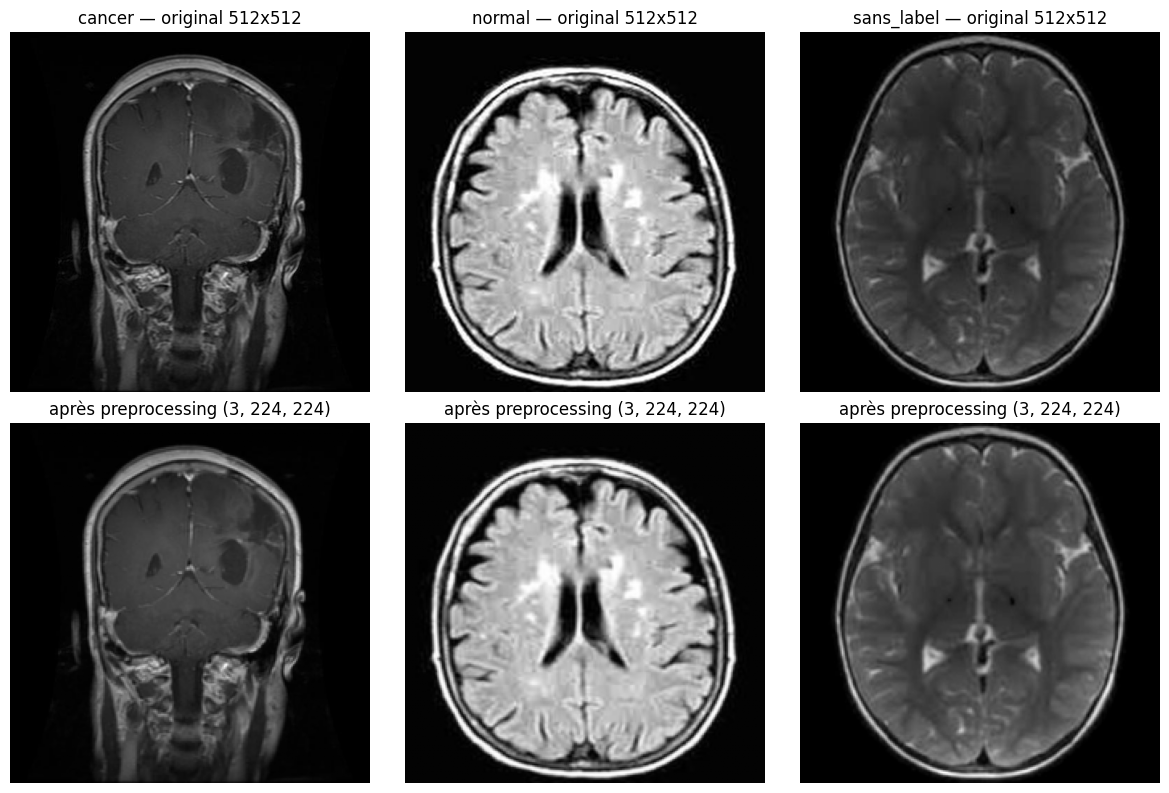

In [12]:
sample = df_clean.groupby("groupe").sample(1, random_state=0)

fig, axes = plt.subplots(2, len(sample), figsize=(4 * len(sample), 8))
for col, (_, row) in enumerate(sample.iterrows()):
    tensor = preprocess(Image.open(row["path"]))
    # Annule la normalisation sur le premier canal (les 3 sont identiques) pour afficher l'image
    displayed = tensor[0] * IMAGENET_STD[0] + IMAGENET_MEAN[0]

    axes[0, col].imshow(Image.open(row["path"]), cmap="gray")
    axes[0, col].set_title(f"{row['groupe']} — original 512x512")
    axes[1, col].imshow(displayed, cmap="gray")
    axes[1, col].set_title(f"après preprocessing {tuple(tensor.shape)}")
    for ax in axes[:, col]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### 2.3 Chargement du modèle

On charge ResNet50 avec ses poids ImageNet, puis :
- on remplace sa dernière couche (`fc`, qui classait les 1 000 catégories d'ImageNet) par une **identité** : le réseau renvoie alors directement le vecteur de 2 048 valeurs issu de la couche `avgpool` ;
- on **gèle** tous les poids (`requires_grad = False`) : aucun paramètre ne sera modifié ;
- on passe en mode **évaluation** (`eval()`), pour que la batch normalization utilise ses statistiques mémorisées plutôt que celles du lot en cours.

Le calcul se fait sur le GPU s'il y en a un : `mps` sur Mac, `cuda` sur Colab, sinon le CPU.

In [13]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = torch.nn.Identity()          # on retire la couche de classification ImageNet
for param in model.parameters():
    param.requires_grad = False         # couches gelées
model = model.eval().to(device)

print(f"Calcul sur : {device}")

Calcul sur : mps


### 2.4 Extraction des embeddings sur deux couches

On extrait les features à **deux profondeurs** du réseau, pour les comparer au clustering :

| Couche | Taille | Ce qu'elle capte |
| --- | --- | --- |
| `avgpool` (sortie finale) | 2 048 | Des représentations de haut niveau, les plus spécialisées pour les objets d'ImageNet |
| `layer3` (intermédiaire) | 1 024 | Des textures et des motifs, plus génériques, qui se transfèrent parfois mieux vers un domaine éloigné comme l'IRM |

La sortie de `layer3` est une carte de 1 024 × 14 × 14 : on en fait la moyenne spatiale pour obtenir un vecteur de 1 024 valeurs. On la récupère avec un *hook*, une fonction appelée automatiquement quand les données traversent la couche : les deux embeddings sortent donc du même passage dans le réseau.

Les images sont traitées par lots de 32, sans calcul de gradient (`torch.no_grad()`), puisqu'on n'entraîne rien.

In [14]:
layer3_output = {}

def save_layer3(module, inputs, output):
    """Hook : moyenne spatiale de la sortie de layer3, (batch, 1024, 14, 14) -> (batch, 1024)."""
    layer3_output["features"] = output.mean(dim=(2, 3))

hook = model.layer3.register_forward_hook(save_layer3)

BATCH_SIZE = 32
paths = df_clean["path"].tolist()
feats_avgpool, feats_layer3 = [], []

with torch.no_grad():
    for start in range(0, len(paths), BATCH_SIZE):
        batch = torch.stack([preprocess(Image.open(p)) for p in paths[start:start + BATCH_SIZE]])
        feats_avgpool.append(model(batch.to(device)).cpu())      # sortie avgpool (2048)
        feats_layer3.append(layer3_output["features"].cpu())     # sortie layer3 (1024), via le hook

hook.remove()  # on retire le hook pour ne pas le cumuler si la cellule est relancée

emb_avgpool = torch.cat(feats_avgpool).numpy()
emb_layer3 = torch.cat(feats_layer3).numpy()

print(f"avgpool : {emb_avgpool.shape}")
print(f"layer3  : {emb_layer3.shape}")

avgpool : (1410, 2048)
layer3  : (1410, 1024)


### 2.5 Sauvegarde

Les embeddings sont sauvegardés au format `.npy`. La ligne *i* de chaque fichier correspond à la ligne *i* de `inventaire_images.csv` : c'est ce qui permet de retrouver l'image et son label à partir d'un embedding.

In [15]:
assert len(emb_avgpool) == len(emb_layer3) == len(inventaire)
assert np.isfinite(emb_avgpool).all() and np.isfinite(emb_layer3).all()

np.save(OUTPUT_DIR / "emb_resnet50_avgpool.npy", emb_avgpool)
np.save(OUTPUT_DIR / "emb_resnet50_layer3.npy", emb_layer3)

print("Embeddings sauvegardés dans", OUTPUT_DIR)

Embeddings sauvegardés dans ../outputs


### 2.6 Recherche de quasi-doublons

L'empreinte MD5 ne repère que les fichiers strictement identiques. Une image recadrée, recompressée ou légèrement éclaircie a une empreinte différente, mais un embedding presque identique.

On calcule la **similarité cosinus** entre tous les couples d'embeddings `avgpool`. Elle vaut 1 quand deux vecteurs pointent exactement dans la même direction. Les couples les plus proches sont affichés côte à côte pour juger à l'œil s'il s'agit de la même image.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(emb_avgpool)
i, j = np.triu_indices_from(sim, k=1)   # chaque couple une seule fois, sans la diagonale
pairs = pd.DataFrame({"i": i, "j": j, "similarite": sim[i, j]})
pairs["groupe_i"] = df_clean["groupe"].values[pairs["i"]]
pairs["groupe_j"] = df_clean["groupe"].values[pairs["j"]]
pairs = pairs.sort_values("similarite", ascending=False).reset_index(drop=True)

for seuil in [0.99, 0.98, 0.97, 0.95]:
    above = pairs[pairs["similarite"] >= seuil]
    cross = (above["groupe_i"] != above["groupe_j"]).sum()
    print(f"similarité >= {seuil} : {len(above):4d} couples, dont {cross} entre groupes différents")

pairs.head(10)

similarité >= 0.99 :   11 couples, dont 1 entre groupes différents
similarité >= 0.98 :   30 couples, dont 3 entre groupes différents
similarité >= 0.97 :   46 couples, dont 4 entre groupes différents
similarité >= 0.95 :  119 couples, dont 19 entre groupes différents


,i,j,similarite,groupe_i,groupe_j
0,357,1234,0.995842,sans_label,sans_label
1,506,690,0.995631,sans_label,sans_label
2,1122,1381,0.994901,sans_label,sans_label
3,133,402,0.992677,sans_label,sans_label
4,155,458,0.991999,sans_label,sans_label
5,282,334,0.991777,sans_label,sans_label
6,69,334,0.991391,normal,sans_label
7,517,1185,0.991112,sans_label,sans_label
8,195,1011,0.991094,sans_label,sans_label
9,493,1241,0.990738,sans_label,sans_label


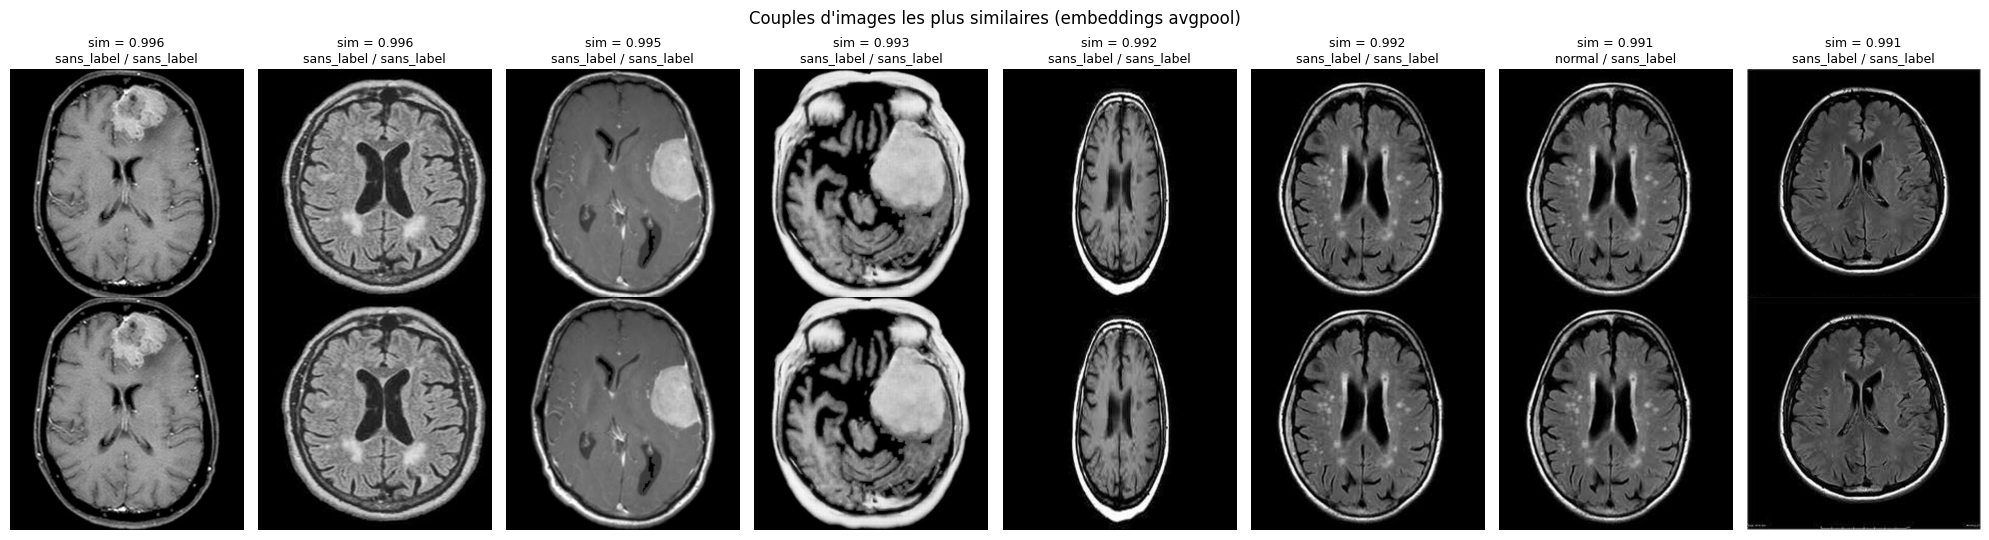

In [17]:
N_PAIRS = 8
fig, axes = plt.subplots(2, N_PAIRS, figsize=(2.5 * N_PAIRS, 5.5))
for k, row in pairs.head(N_PAIRS).iterrows():
    for r, idx in enumerate([row["i"], row["j"]]):
        axes[r, k].imshow(Image.open(df_clean.loc[idx, "path"]), cmap="gray")
        axes[r, k].axis("off")
    # Un seul titre par couple : similarité et groupes des deux images
    axes[0, k].set_title(f"sim = {row['similarite']:.3f}\n{row['groupe_i']} / {row['groupe_j']}", fontsize=9)
plt.suptitle("Couples d'images les plus similaires (embeddings avgpool)")
plt.tight_layout()
plt.show()

**Lecture des résultats.** Les couples au-dessus de 0,99 sont la même image recompressée. En dessous, on trouve aussi des **copies transformées** : la même coupe éclaircie, recadrée ou zoomée, parfois reconnaissable à un même filigrane. L'écart de pixels ne permet pas de les repérer, mais leur similarité d'embedding reste autour de 0,95 à 0,97. Sous 0,95, les couples sont en majorité des images différentes qui se ressemblent (même plan de coupe, même séquence).

Deux problèmes en découlent :
- **Fuite de données** : jusqu'à 19 images sans label sont des quasi-copies d'images labellisées.
- **Doublons dans le jeu fort** : 4 couples d'images `normal` sont des quasi-copies. À l'étape 4, une copie pourrait finir dans le train et l'autre dans le test, ce qui gonflerait les scores.

### 2.7 Retrait des quasi-doublons

On applique la même règle qu'au dédoublonnage MD5, avec un critère de similarité à la place de l'empreinte :

- **Seuil : 0,95.** C'est un choix prudent. Une fuite fausserait toute la comparaison entre supervisé et semi-supervisé, qui est le cœur du projet, alors que perdre environ 7 % des images sans label coûte peu. La contrepartie : quelques images seulement ressemblantes sont retirées aussi.
- **Priorité aux images labellisées** : on passe en revue les images labellisées d'abord, puis les images sans label. Chaque image est conservée seulement si elle n'est pas trop proche d'une image déjà conservée.

| Seuil (estimation préalable) | Fuites vers les labellisés | Images sans label retirées |
| --- | --- | --- |
| 0,99 | 1 | 9 |
| 0,97 | 4 | 37 |
| **0,95** | **19** | **98** |

À l'issue de cette section, l'inventaire et les deux fichiers d'embeddings sont **réécrits dans leur version filtrée**. Ce sont eux qui servent de référence pour la suite.

In [18]:
SEUIL_QUASI_DOUBLON = 0.95

# Ordre de passage : images labellisées d'abord (False < True), pour qu'elles priment sur leurs copies
order = np.argsort(df_clean["subset"].ne("avec_labels").values, kind="stable")

kept = []
for idx in order:
    # On écarte l'image si elle est trop proche d'une image déjà conservée
    if kept and sim[idx, kept].max() >= SEUIL_QUASI_DOUBLON:
        continue
    kept.append(idx)

keep_mask = np.zeros(len(df_clean), dtype=bool)
keep_mask[kept] = True

pd.DataFrame({
    "avant": df_clean["groupe"].value_counts(),
    "après": df_clean.loc[keep_mask, "groupe"].value_counts(),
}).assign(retirées=lambda t: t["avant"] - t["après"])

,avant,après,retirées
groupe,,,
sans_label,1311,1214,97
cancer,50,50,0
normal,49,46,3


In [19]:
# Filtrage cohérent du DataFrame, de l'inventaire et des deux jeux d'embeddings (mêmes lignes partout)
df_clean = df_clean[keep_mask].reset_index(drop=True)
inventaire = inventaire[keep_mask].reset_index(drop=True)
emb_avgpool = emb_avgpool[keep_mask]
emb_layer3 = emb_layer3[keep_mask]

# Vérification : plus aucun couple d'images au-dessus du seuil
check = cosine_similarity(emb_avgpool)
np.fill_diagonal(check, 0)
assert check.max() < SEUIL_QUASI_DOUBLON

# Sauvegarde des versions finales (écrase les fichiers précédents)
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)
np.save(OUTPUT_DIR / "emb_resnet50_avgpool.npy", emb_avgpool)
np.save(OUTPUT_DIR / "emb_resnet50_layer3.npy", emb_layer3)

print(f"Similarité maximale restante : {check.max():.4f}")
print(f"Jeu final : {len(df_clean)} images | avgpool {emb_avgpool.shape} | layer3 {emb_layer3.shape}")

Similarité maximale restante : 0.9499
Jeu final : 1310 images | avgpool (1310, 2048) | layer3 (1310, 1024)


### 2.8 Observations

**Preprocessing et extraction**
- Le preprocessing ne déforme pas les images : on passe d'un carré de 512 à un carré de 224. La conversion en gris sur 3 canaux efface au passage les bandeaux bleus des captures d'écran.
- L'extraction ne prend que quelques secondes sur le GPU d'un Mac (MPS) : Colab n'est pas nécessaire pour cette étape, puisque rien n'est entraîné.
- On dispose de deux représentations de chaque image, `avgpool` (2 048 valeurs) et `layer3` (1 024 valeurs). Elles seront comparées au clustering.

**Quasi-doublons**
- Les embeddings ont révélé des doublons que le MD5 ne pouvait pas détecter : des **copies transformées** d'une même image (recompressée, éclaircie, recadrée).
- Au seuil de similarité de 0,95, on retire 97 images sans label et 3 images normales. Cela élimine les fuites entre jeu faible et jeu fort, ainsi que les doublons internes au jeu fort.

**Jeu final : 1 310 images**

| Groupe | Images |
| --- | --- |
| cancer | 50 |
| normal | 46 |
| sans label | 1 214 |

Au total, le nettoyage a ramené les 1 506 fichiers d'origine à 1 310 images réellement distinctes, soit **13 % de redondance**.

**Ce que ça dit du jeu de données**
- Filigranes de sites web, captures d'écran de visionneuse, copies transformées, séquences hétérogènes : le jeu semble **compilé à partir de sources variées**, pas issu d'un protocole d'acquisition unique.
- C'est un enseignement pour le passage à l'échelle à 4 millions d'images : l'étape de **contrôle qualité et de dédoublonnage** doit faire partie du pipeline, sinon les métriques mesurées seront trompeuses.
- Le jeu fort ne compte plus que 96 images : le jeu de test de l'étape 4 sera petit, et les métriques devront être lues avec prudence.

**Pour l'étape 3**
- Standardiser les embeddings avant la PCA, puisque les dimensions n'ont pas la même échelle.
- Comparer `avgpool` et `layer3`, en gardant en tête le biais de séquence observé à l'étape 1.

---

## Étape 3 — Réduction de dimension, clustering et labels faibles

L'idée : si les embeddings capturent la présence d'une tumeur, les images devraient se regrouper naturellement en deux ensembles, sains et tumoraux, **sans qu'on ait besoin de labels**. On cherche ces regroupements, on vérifie avec les labels des radiologues qu'ils ont un sens médical, puis on s'en sert pour étiqueter les images sans label. C'est la labellisation « faible ».

### 3.1 Découpage train / test du jeu fort

On fixe **dès maintenant** le découpage du jeu fortement labellisé, qui servira aussi à l'étape 4 :
- le **train** (70 %) sert à évaluer les clusterings, à choisir le meilleur, et à décider quel cluster correspond au cancer ;
- le **test** (30 %) n'est **jamais utilisé** à l'étape 3. Il reste intact pour évaluer les modèles de l'étape 4 sur des images qu'aucune étape n'a vues.

Le découpage est **stratifié** : on garde la même proportion cancer / normal dans le train et dans le test. Il est enregistré dans l'inventaire (colonne `split_fort`).

In [20]:
from sklearn.model_selection import train_test_split

labeled_idx = df_clean.index[df_clean["subset"] == "avec_labels"]
train_idx, test_idx = train_test_split(
    labeled_idx,
    test_size=0.3,
    stratify=df_clean.loc[labeled_idx, "label"],   # même proportion cancer / normal des deux côtés
    random_state=42,
)

df_clean["split_fort"] = None
df_clean.loc[train_idx, "split_fort"] = "train"
df_clean.loc[test_idx, "split_fort"] = "test"

inventaire["split_fort"] = df_clean["split_fort"]
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)

pd.crosstab(df_clean["groupe"], df_clean["split_fort"].fillna("-"), margins=True)

split_fort,-,test,train,All
groupe,,,,
cancer,0,15,35,50
normal,0,14,32,46
sans_label,1214,0,0,1214
All,1214,29,67,1310


### 3.2 Standardisation

Chaque dimension d'un embedding a sa propre échelle. Sans standardisation, les dimensions aux grandes valeurs domineraient les calculs de distance du clustering et de la PCA. On ramène donc chaque dimension à une moyenne de 0 et un écart-type de 1.

La standardisation est ajustée sur toutes les images, sans utiliser aucun label.

In [21]:
from sklearn.preprocessing import StandardScaler

embeddings = {"avgpool": emb_avgpool, "layer3": emb_layer3}
scaled = {name: StandardScaler().fit_transform(emb) for name, emb in embeddings.items()}

for name, X in scaled.items():
    print(f"{name:8s} {X.shape} | moyenne {X.mean():.2f} | écart-type {X.std():.2f}")

avgpool  (1310, 2048) | moyenne -0.00 | écart-type 1.00
layer3   (1310, 1024) | moyenne -0.00 | écart-type 1.00


### 3.3 Réduction de dimension par PCA

Le clustering fonctionne mal en très grande dimension : avec 2 048 dimensions, toutes les distances entre points finissent par se ressembler (c'est le *fléau de la dimension*). On réduit donc les embeddings avec une **PCA** (analyse en composantes principales), qui garde les directions portant le plus de variance.

La courbe de variance expliquée cumulée aide à choisir le nombre de composantes. On retient **50 composantes** pour les deux couches : un compromis entre information conservée et dimension raisonnable pour le clustering.

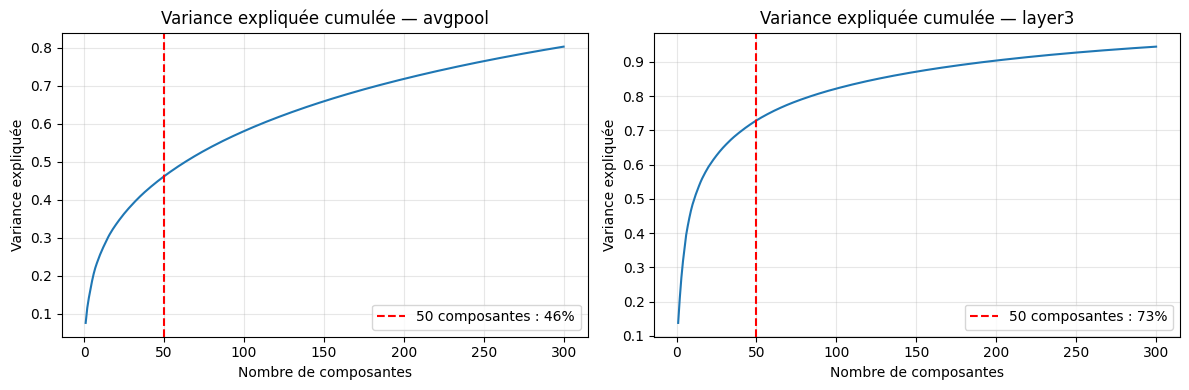

In [22]:
from sklearn.decomposition import PCA

N_COMPONENTS = 50

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, X) in zip(axes, scaled.items()):
    cum_var = np.cumsum(PCA(random_state=42).fit(X).explained_variance_ratio_)
    ax.plot(np.arange(1, 301), cum_var[:300])
    ax.axvline(N_COMPONENTS, color="red", linestyle="--", label=f"{N_COMPONENTS} composantes : {cum_var[N_COMPONENTS - 1]:.0%}")
    ax.set_title(f"Variance expliquée cumulée — {name}")
    ax.set_xlabel("Nombre de composantes")
    ax.set_ylabel("Variance expliquée")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# Embeddings réduits à 50 dimensions : ce sont eux qui servent au clustering
reduced = {name: PCA(N_COMPONENTS, random_state=42).fit_transform(X) for name, X in scaled.items()}

On visualise les images sur les **deux premières composantes** de la PCA, en colorant les images labellisées. Si les deux classes se séparaient nettement ici, le clustering serait facile.

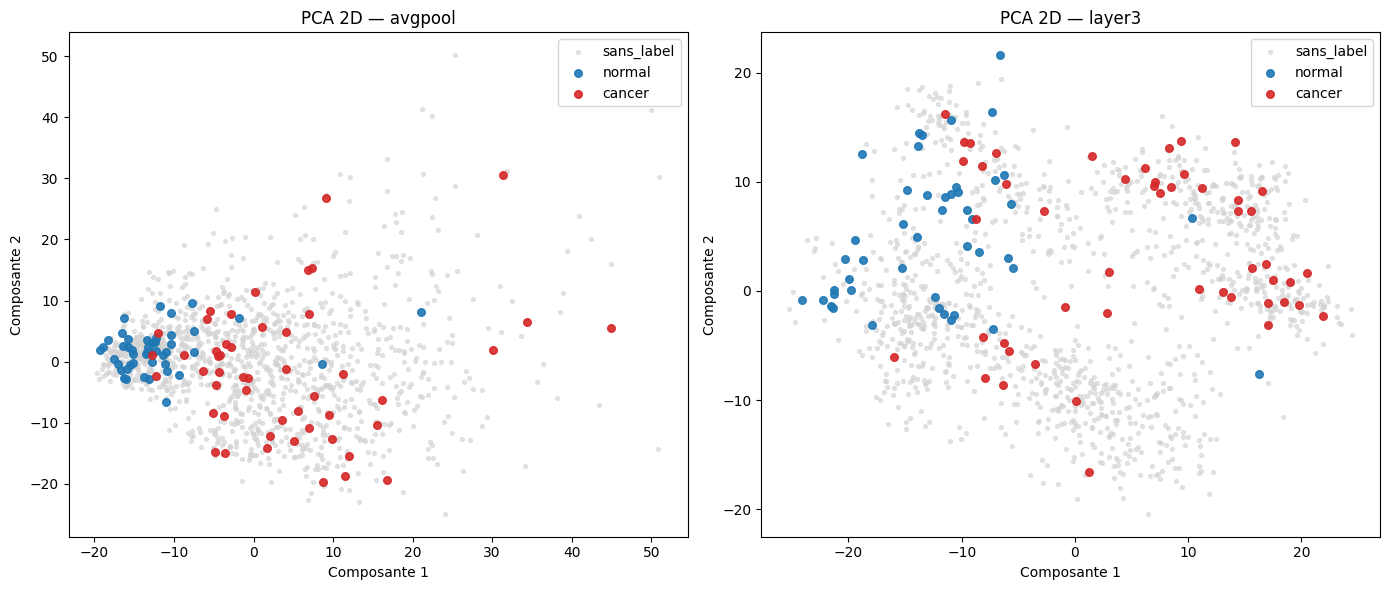

In [23]:
COLORS = {"sans_label": "lightgrey", "normal": "tab:blue", "cancer": "tab:red"}

def plot_groups(ax, coords, title):
    """Nuage de points 2D, coloré par groupe (images sans label en fond, en gris)."""
    for groupe in ["sans_label", "normal", "cancer"]:
        mask = (df_clean["groupe"] == groupe).values
        ax.scatter(coords[mask, 0], coords[mask, 1], c=COLORS[groupe], label=groupe,
                   s=8 if groupe == "sans_label" else 30, alpha=0.6 if groupe == "sans_label" else 0.9)
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, Z) in zip(axes, reduced.items()):
    plot_groups(ax, Z[:, :2], f"PCA 2D — {name}")
    ax.set_xlabel("Composante 1")
    ax.set_ylabel("Composante 2")
plt.tight_layout()
plt.show()

### 3.4 Visualisation par t-SNE

La PCA est une projection **linéaire** : elle peut écraser des structures plus complexes. Le **t-SNE** est une méthode non linéaire qui cherche à préserver les voisinages : deux images proches dans l'espace des embeddings restent proches sur le graphique.

Attention : le t-SNE sert **uniquement à la visualisation**. Il déforme les distances globales (la taille des amas et l'écart entre eux n'ont pas de sens), donc on ne fait pas de clustering dessus. On l'applique sur les 50 composantes de la PCA, ce qui est la pratique courante.

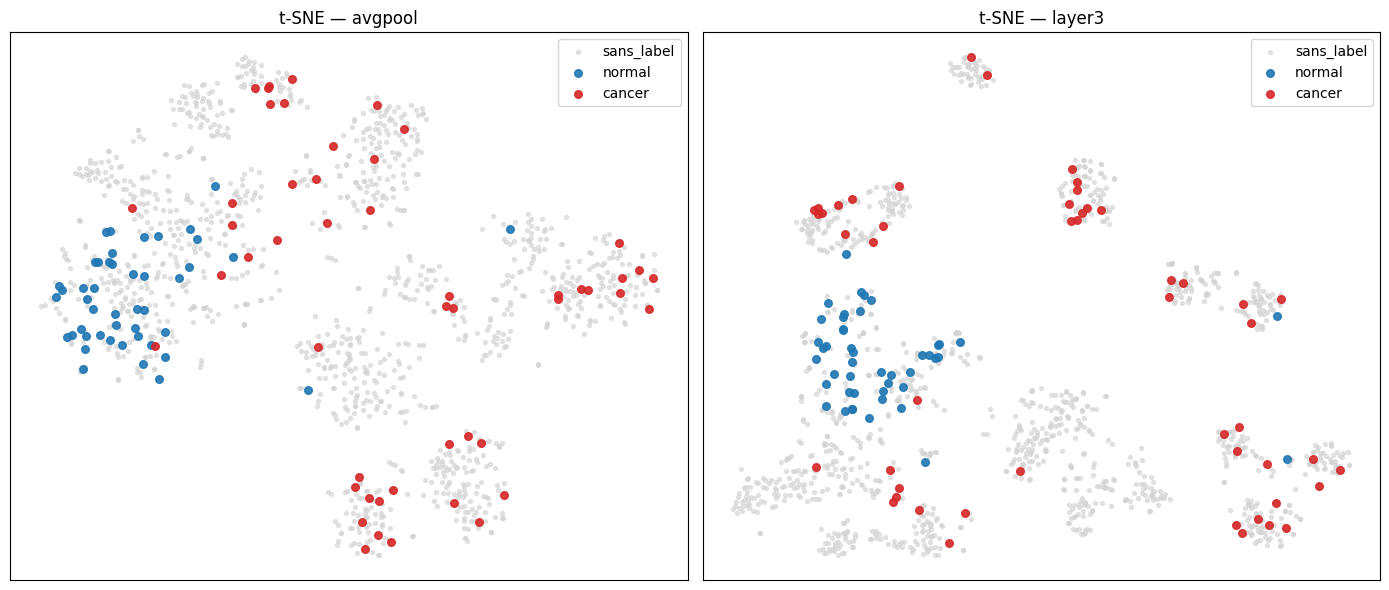

In [24]:
from sklearn.manifold import TSNE

tsne = {name: TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Z) for name, Z in reduced.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, T) in zip(axes, tsne.items()):
    plot_groups(ax, T, f"t-SNE — {name}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

### 3.5 Clustering : quatre algorithmes

On teste quatre familles d'algorithmes, chacune avec une autre définition de ce qu'est un « groupe » :

| Algorithme | Principe | Nombre de groupes |
| --- | --- | --- |
| **K-Means** | Chaque point rejoint le centre le plus proche ; les centres sont recalculés jusqu'à stabilité. Il suppose des groupes sphériques de tailles comparables. | Fixé à 2 |
| **CAH (Ward)** | Classification ascendante hiérarchique : on part d'un point par groupe et on fusionne à chaque étape les deux groupes dont l'union augmente le moins la variance interne. | Fixé à 2 |
| **Mélange gaussien** | On modélise les données comme un mélange de 2 lois normales. C'est un clustering « souple » : chaque point reçoit une probabilité d'appartenance, et les groupes peuvent être allongés. | Fixé à 2 |
| **DBSCAN** | Un groupe est une zone **dense** de points. Les points isolés sont classés comme du bruit (label `-1`). | Trouvé par l'algorithme |

Tous sont ajustés sur les 1 310 images, **sans aucun label**.

**Réglage de DBSCAN.** DBSCAN a deux paramètres : `min_samples`, le nombre de voisins requis pour former une zone dense (on prend 10), et `eps`, le rayon de voisinage. Pour choisir `eps`, on trace pour chaque point la distance à son 10ᵉ voisin, triée par ordre croissant. Le « coude » de la courbe sépare les points des zones denses des points isolés. On le situe autour du **90ᵉ percentile**.

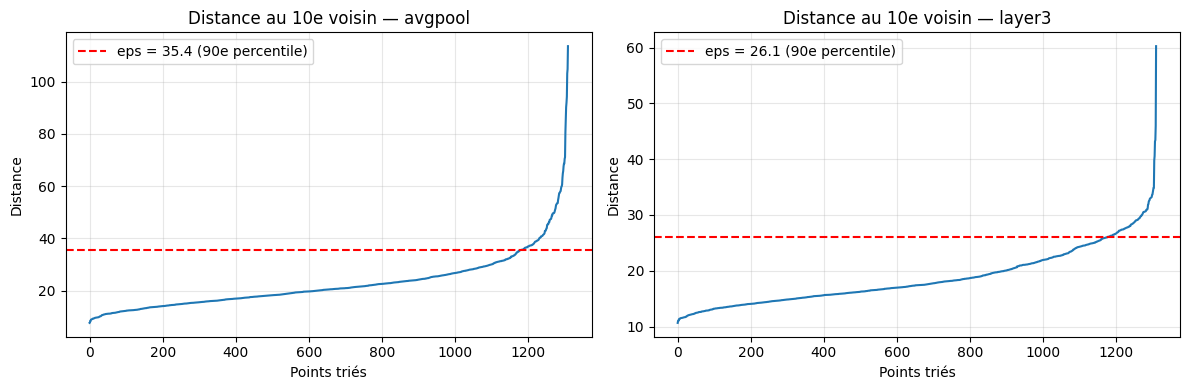

nb clusters        part de bruit       
couche             avgpool layer3       avgpool layer3
percentile eps                                        
50                       1      7           33%    34%
70                       1      3           19%    19%
80                       1      1           11%    10%
90                       1      1            5%     4%
95                       1      1            3%     1%

In [25]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

MIN_SAMPLES = 10
eps_dbscan = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, Z) in zip(axes, reduced.items()):
    # Distance de chaque point à son 10e voisin, triée
    k_dist = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z).kneighbors(Z)[0][:, -1])
    eps_dbscan[name] = np.percentile(k_dist, 90)
    ax.plot(k_dist)
    ax.axhline(eps_dbscan[name], color="red", linestyle="--", label=f"eps = {eps_dbscan[name]:.1f} (90e percentile)")
    ax.set_title(f"Distance au {MIN_SAMPLES}e voisin — {name}")
    ax.set_xlabel("Points triés")
    ax.set_ylabel("Distance")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# Sensibilité de DBSCAN à eps : nombre de clusters et part de bruit
rows = []
for name, Z in reduced.items():
    k_dist = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z).kneighbors(Z)[0][:, -1])
    for pct in [50, 70, 80, 90, 95]:
        labels = DBSCAN(eps=np.percentile(k_dist, pct), min_samples=MIN_SAMPLES).fit_predict(Z)
        rows.append({"couche": name, "percentile eps": pct, "nb clusters": len(set(labels) - {-1}),
                     "part de bruit": f"{(labels == -1).mean():.0%}"})
pd.DataFrame(rows).pivot(index="percentile eps", columns="couche", values=["nb clusters", "part de bruit"])

### 3.6 Évaluation des clusterings

Deux mesures complémentaires :

- **ARI** (*Adjusted Rand Index*) : il mesure l'accord entre les clusters et les **vrais labels** des radiologues, calculé sur les images du **train** du jeu fort. Il vaut 1 si les clusters reproduisent parfaitement les labels, environ 0 pour un regroupement au hasard, et il peut être négatif. Il ne dépend pas du numéro attribué aux clusters. C'est la vérification recommandée : confronter le clustering à des images labellisées historiquement.
- **Silhouette** : elle mesure la qualité **interne** des clusters, sans aucun label. Pour chaque point, on compare la distance moyenne à son propre groupe et au groupe voisin. Elle va de -1 à 1 : plus elle est élevée, plus les groupes sont compacts et bien séparés.

Une bonne silhouette avec un ARI faible signifierait que les images se regroupent bien… mais selon un autre critère que la tumeur.

In [26]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

train_mask = (df_clean["split_fort"] == "train").values
y_train = df_clean.loc[train_mask, "label"].values

def run_clusterings(Z, eps):
    """Applique les 4 algorithmes sur les embeddings réduits et renvoie les clusters obtenus."""
    return {
        "K-Means": KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Z),
        "CAH (Ward)": AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(Z),
        "Mélange gaussien": GaussianMixture(n_components=2, random_state=42).fit_predict(Z),
        "DBSCAN": DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Z),
    }

clusters, rows = {}, []
for name, Z in reduced.items():
    for algo, labels in run_clusterings(Z, eps_dbscan[name]).items():
        clusters[(name, algo)] = labels
        not_noise = labels != -1
        n_clusters = len(set(labels[not_noise]))
        rows.append({
            "couche": name,
            "algorithme": algo,
            "nb clusters": n_clusters,
            "bruit": f"{(~not_noise).mean():.0%}",
            # Le bruit de DBSCAN (-1) compte comme un groupe à part entière dans l'ARI
            "ARI (train fort)": adjusted_rand_score(y_train, labels[train_mask]),
            # La silhouette exige au moins 2 clusters ; elle est calculée hors bruit
            "silhouette": silhouette_score(Z[not_noise], labels[not_noise]) if n_clusters >= 2 else np.nan,
        })

results = pd.DataFrame(rows).sort_values("ARI (train fort)", ascending=False).reset_index(drop=True)
results.round(3)

,couche,algorithme,nb clusters,bruit,ARI (train fort),silhouette
0,avgpool,CAH (Ward),2,0%,0.484,0.094
1,layer3,K-Means,2,0%,0.443,0.151
2,layer3,Mélange gaussien,2,0%,0.443,0.151
3,layer3,CAH (Ward),2,0%,0.329,0.140
4,avgpool,K-Means,2,0%,0.295,0.152
5,avgpool,Mélange gaussien,2,0%,0.203,0.147
6,layer3,DBSCAN,1,4%,0.007,NaN
7,avgpool,DBSCAN,1,5%,-0.003,NaN


### 3.7 Le meilleur clustering voit-il la tumeur ?

On retient la combinaison couche × algorithme qui a le **meilleur ARI**. On la regarde sous trois angles :
1. la répartition des labels du train fort dans chaque cluster ;
2. les clusters sur le t-SNE, à côté des vrais labels ;
3. des images tirées au hasard dans chaque cluster, et leur luminosité moyenne, pour tester l'hypothèse de l'étape 1 : les clusters suivent-ils la tumeur, ou la séquence d'acquisition ?

In [27]:
best = results.iloc[0]
best_layer, best_algo = best["couche"], best["algorithme"]
best_clusters = clusters[(best_layer, best_algo)]
df_clean["cluster"] = best_clusters

print(f"Meilleur clustering : {best_algo} sur {best_layer} (ARI = {best['ARI (train fort)']:.3f})\n")

# Répartition des labels du train fort dans chaque cluster
pd.crosstab(df_clean.loc[train_mask, "cluster"], df_clean.loc[train_mask, "label"], margins=True)

Meilleur clustering : CAH (Ward) sur avgpool (ARI = 0.484)



label,cancer,normal,All
cluster,,,
0,27,2,29
1,8,30,38
All,35,32,67


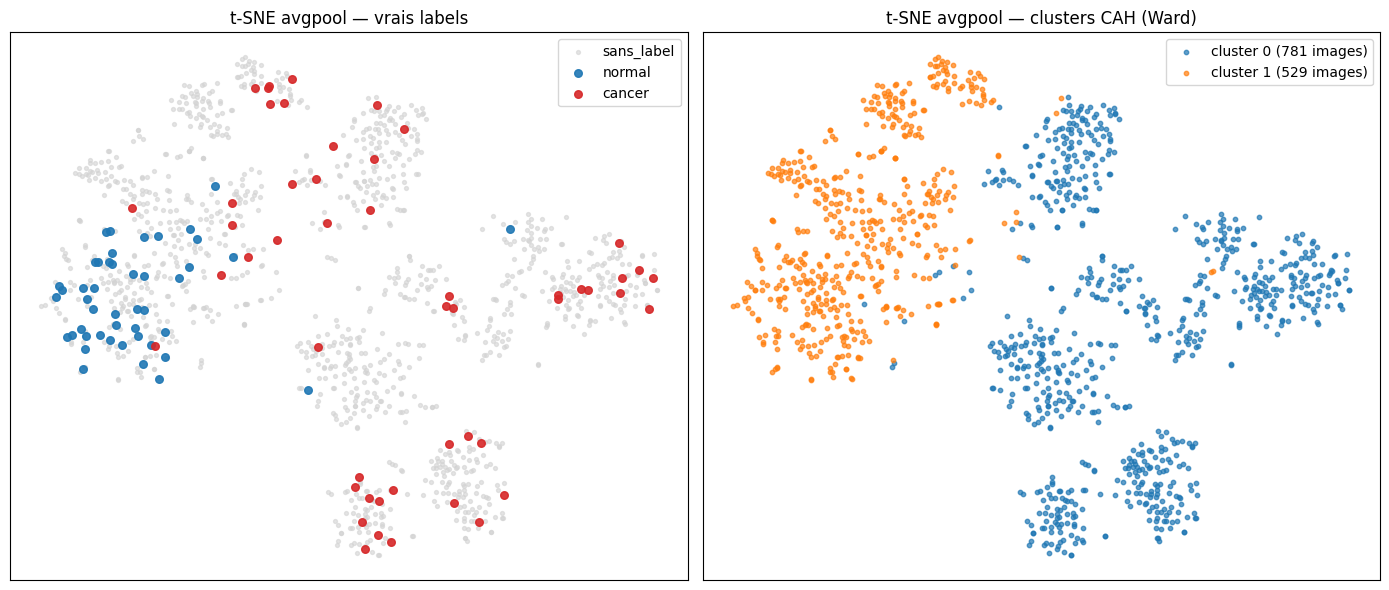

In [28]:
T = tsne[best_layer]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_groups(axes[0], T, f"t-SNE {best_layer} — vrais labels")

for c in sorted(set(best_clusters)):
    mask = best_clusters == c
    axes[1].scatter(T[mask, 0], T[mask, 1], s=10, alpha=0.7, label=f"cluster {c} ({mask.sum()} images)")
axes[1].set_title(f"t-SNE {best_layer} — clusters {best_algo}")
axes[1].legend()

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

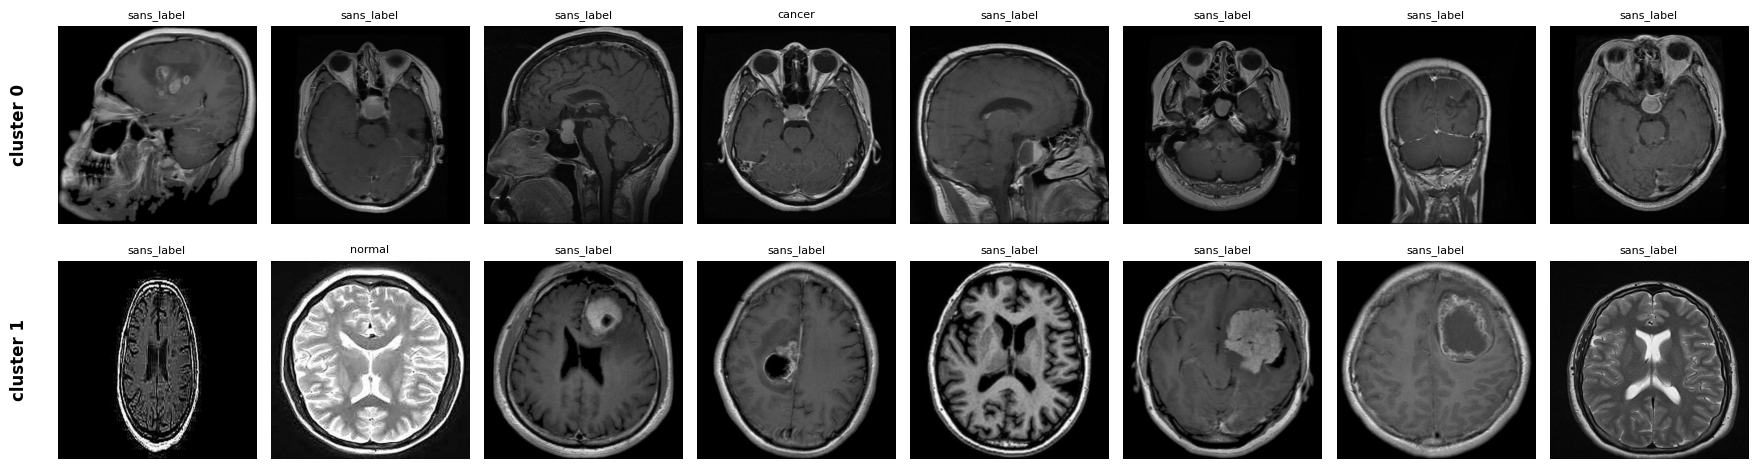

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,781.0,49.4,13.1,17.7,41.3,49.0,54.7,136.2
1,529.0,54.3,20.6,14.9,39.7,52.5,65.7,115.3


In [29]:
N_PER_CLUSTER = 8
cluster_ids = sorted(set(best_clusters))

fig, axes = plt.subplots(len(cluster_ids), N_PER_CLUSTER, figsize=(2.2 * N_PER_CLUSTER, 2.5 * len(cluster_ids)))
for row, c in enumerate(cluster_ids):
    sample = df_clean[df_clean["cluster"] == c].sample(N_PER_CLUSTER, random_state=0)
    for col, (_, r) in enumerate(sample.iterrows()):
        axes[row, col].imshow(Image.open(r["path"]), cmap="gray")
        axes[row, col].set_title(r["groupe"], fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].text(-0.15, 0.5, f"cluster {c}", transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Luminosité moyenne par cluster (hypothèse du biais de séquence)
df_clean.groupby("cluster")["mean_intensity"].describe().round(1)

### 3.8 Labels faibles

On transforme les clusters en labels :
1. chaque cluster reçoit la **classe majoritaire** des images du train fort qu'il contient ;
2. chaque image sans label reçoit la classe de son cluster.

Pour suivre les mêmes métriques que dans la suite du projet (accuracy, F1, AUC), il faut aussi un **score continu** : l'AUC évalue un classement, pas une décision binaire. On calcule un score de « cancer » à partir de la position de chaque image entre les deux centres de clusters : la distance au centre du cluster normal, moins la distance au centre du cluster cancer. Plus il est élevé, plus l'image est du côté cancer.

Ces métriques, calculées sur le train fort, donnent une **estimation de la qualité des labels faibles**. Elles sont un peu optimistes, puisque ces mêmes images ont servi à associer les clusters aux classes.

Les labels faibles sont sauvegardés dans un fichier **à part**, `labels_faibles.csv`, qui ne contient que des images sans label : ils ne sont jamais mélangés aux labels forts.

In [30]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Chaque cluster reçoit la classe majoritaire des images du train fort qu'il contient
train_labeled = df_clean[train_mask]
cluster_to_label = train_labeled.groupby("cluster")["label"].agg(lambda s: s.value_counts().idxmax()).to_dict()
print("Association cluster -> classe :", cluster_to_label)
df_clean["label_cluster"] = df_clean["cluster"].map(cluster_to_label)

# 2. Score continu de « cancer » : distance au centre normal - distance au centre cancer
Z_best = reduced[best_layer]
centre = {lab: Z_best[df_clean["label_cluster"].values == lab].mean(axis=0) for lab in ["cancer", "normal"]}
df_clean["score_cancer"] = (np.linalg.norm(Z_best - centre["normal"], axis=1)
                            - np.linalg.norm(Z_best - centre["cancer"], axis=1))

# 3. Qualité estimée des labels faibles, sur le train fort (cancer = classe positive)
eval_df = df_clean[train_mask]
y_true = (eval_df["label"] == "cancer").astype(int)
y_pred = (eval_df["label_cluster"] == "cancer").astype(int)
pd.Series({
    "accuracy": accuracy_score(y_true, y_pred),
    "F1 (cancer)": f1_score(y_true, y_pred),
    "AUC": roc_auc_score(y_true, eval_df["score_cancer"]),
}, name="qualité des labels faibles (train fort)").round(3)

Association cluster -> classe : {0: 'cancer', 1: 'normal'}


accuracy       0.851
F1 (cancer)    0.844
AUC            0.926
Name: qualité des labels faibles (train fort), dtype: float64

In [31]:
# Sauvegarde des labels faibles : images sans label uniquement, dans un fichier séparé
weak = df_clean[df_clean["subset"] == "sans_label"].copy()
weak["path"] = weak["path"].apply(lambda p: p.relative_to(DATA_DIR).as_posix())
weak = weak.rename(columns={"label_cluster": "label_faible"})[["path", "label_faible", "score_cancer", "cluster"]]
weak.to_csv(OUTPUT_DIR / "labels_faibles.csv", index=False)

print(f"{len(weak)} labels faibles sauvegardés dans {OUTPUT_DIR / 'labels_faibles.csv'}")
weak["label_faible"].value_counts()

1214 labels faibles sauvegardés dans ../outputs/labels_faibles.csv


label_faible
cancer    742
normal    472
Name: count, dtype: int64

### 3.9 Observations

**Réduction de dimension**
- Avec 50 composantes, la PCA conserve 46 % de la variance pour `avgpool` et 73 % pour `layer3`. L'information de `avgpool` est plus diffuse, répartie sur beaucoup de directions.
- Sur la PCA 2D comme sur le t-SNE, les images `normal` et `cancer` occupent des zones **différentes mais qui se chevauchent**. Les images `normal` forment un groupe assez compact. Les images `cancer` sont réparties sur **plusieurs îlots**, qui semblent correspondre à des plans de coupe ou des séquences différentes.

**Comparaison des clusterings (ARI sur le train fort)**
- Meilleur résultat : **CAH de Ward sur `avgpool`, ARI = 0,48**, suivie de K-Means et du mélange gaussien sur `layer3` (0,44). C'est un accord modéré avec les labels des radiologues, nettement au-dessus du hasard.
- Aucune couche ne domine clairement : `avgpool` donne le meilleur ARI, `layer3` les résultats les plus stables d'un algorithme à l'autre.
- Les **silhouettes sont faibles** (0,09 à 0,15) : les données ne forment pas deux groupes nettement séparés, mais plutôt un continuum.
- **DBSCAN échoue** : quel que soit `eps`, il trouve une seule grande zone dense entourée de bruit, ou une poussière de petits groupes. C'est cohérent avec les silhouettes : il n'y a pas deux amas denses séparés par du vide. DBSCAN n'est pas adapté à ce problème.

**Qualité estimée des labels faibles (train fort)**
- Accuracy 0,85, F1 (cancer) 0,84, AUC 0,93, avec une répartition de 742 cancer pour 472 normal parmi les images sans label.
- Ces chiffres sont **optimistes**, pour deux raisons :
  1. les images du train ont servi à associer les clusters aux classes ;
  2. surtout, le jeu labellisé est lui-même biaisé. Comme vu à l'étape 1, les images `cancer` sont surtout acquises avec une séquence sombre, les `normal` avec d'autres séquences. Un clustering qui sépare les **séquences** obtient donc un bon score sur ce jeu, **même s'il ne voit pas la tumeur**.

**Le clustering voit-il la tumeur ? En partie seulement**
- Le **cluster « cancer »** regroupe surtout des IRM avec la même séquence sombre, dans tous les plans de coupe (axial, sagittal, coronal), y compris des images où aucune tumeur n'est visible.
- Le **cluster « normal »** regroupe surtout les autres séquences, plus claires, mais il contient aussi des **images avec une tumeur clairement visible**.
- La luminosité moyenne diffère peu entre les deux clusters (médianes de 49 et 52,5) : ce n'est pas la luminosité seule qui guide le regroupement, c'est plutôt le **type de séquence** (le contraste entre tissus).
- Conclusion : le clustering capture **d'abord la séquence d'acquisition, et ensuite seulement la tumeur**. L'hypothèse de biais de l'étape 1 est confirmée. Les labels faibles sont donc **bruités**, avec des faux « normal » que l'on peut repérer à l'œil.

**Conséquences pour l'étape 4**
- Les labels faibles restent utiles pour **préentraîner** un CNN, mais il faut s'attendre à ce qu'ils transmettent une partie de ce biais.
- Piste, inspirée de la pseudo-labellisation : ne garder que les labels faibles les plus sûrs, c'est-à-dire les images dont le `score_cancer` est loin de la frontière entre les deux clusters.
- Le jeu de test fort (29 images) n'a été utilisé nulle part : il reste une évaluation honnête pour l'étape 4.